In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import os

In [ ]:
# Load the CSV file (replace 'your_file.csv' with your file name)
df_red = pd.read_csv("lab_red.csv")
df_yellow = pd.read_csv("lab_yellow.csv")
df_blue = pd.read_csv("lab_blue.csv")
df_green = pd.read_csv("lab_green.csv")
df_orange = pd.read_csv("lab_orange.csv")


# Load all CSVs
data_files = {
    "red": "lab_red.csv",
    "yellow": "lab_yellow.csv",
    "blue": "lab_blue.csv",
    "green": "lab_green.csv",
    "orange": "lab_orange.csv"
}


print(df_red.adc35_voltage.head(), df_yellow.adc35_voltage.head(), df_green.adc35_voltage.head(), df_blue.adc35_voltage.head(), df_orange.adc35_voltage.head(), data_files)

0    0.015
1    0.029
2    0.039
3    0.052
4    0.064
Name: adc35_voltage, dtype: float64 0    0.018
1    0.031
2    0.046
3    0.054
4    0.067
Name: adc35_voltage, dtype: float64 0    0.044
1    0.055
2    0.066
3    0.079
4    0.090
Name: adc35_voltage, dtype: float64 0    0.048
1    0.060
2    0.073
3    0.086
4    0.094
Name: adc35_voltage, dtype: float64 0    0.013
1    0.030
2    0.040
3    0.052
4    0.064
Name: adc35_voltage, dtype: float64 {'red': 'lab_red.csv', 'yellow': 'lab_yellow.csv', 'blue': 'lab_blue.csv', 'green': 'lab_green.csv', 'orange': 'lab_orange.csv'}


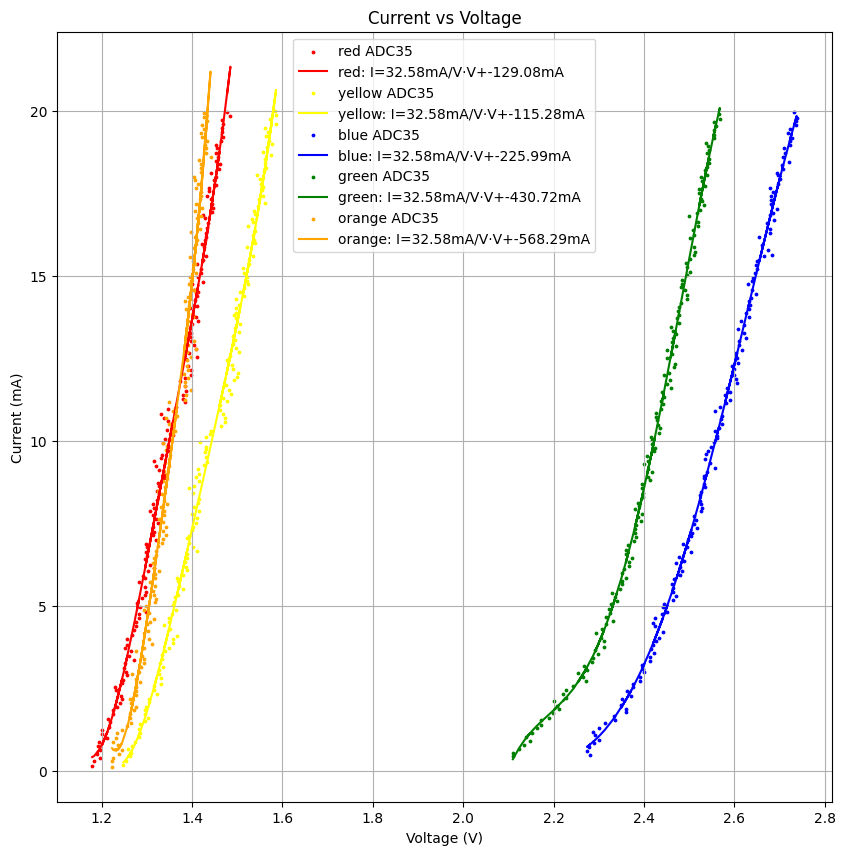

In [ ]:
# matplot

plt.figure(figsize=(10, 10))

for color, file in data_files.items():
    df = pd.read_csv(file)
    
    # Create current variables
    df['V_led']=df['adc34_voltage'] * ((10000+2000)/2000) - df['adc35_voltage']
    df['Iled']=df['adc35_voltage']/100

    df = df[df['Iled'] <= 0.02]

    a, b, c = np.polyfit(df['V_led'], df['Iled'], 2)

    df['fit_old'] = a * df['V_led']**2 + b * df['V_led'] + c

    p = np.poly1d(np.polyfit(df['V_led'], df['Iled'], 4))
    
    df['fit'] = p(df['V_led'])

    # Plot I vs V (using dac_voltage as V)
    plt.scatter(df['V_led'], df['Iled']*1000,
             label=f'{color} ADC35', color=color, s=3)
    
    plt.plot(df['V_led'], df['fit']*1000, 
             label=f'{color}: I={m*1000:.2f}mA/V·V+{b*1000:.2f}mA', color=color)
    


plt.xlabel('Voltage (V)')
plt.ylabel('Current (mA)')
plt.title('Current vs Voltage')
plt.legend()
plt.grid(True)

plt.show()

In [72]:
# Plotly

data_files = {
    "red": "lab_red.csv",
    "yellow": "lab_yellow.csv",
    "blue": "lab_blue.csv",
    "green": "lab_green.csv",
    "orange": "lab_orange.csv"
}

fig = go.Figure()

R = 100  # ohms
V1 = 10



for color, file in data_files.items():
    df = pd.read_csv(file)

    df['V_led']=df['adc34_voltage'] * ((10000+2000)/2000) - df['adc35_voltage']
    df['Iled']=df['adc35_voltage']/100

    df.to_csv(file, index=False)

    df = df[df['Iled'] <= 0.02]

    p = np.poly1d(np.polyfit(df['V_led'], df['Iled'], 4))
    
    df['fit'] = p(df['V_led'])

    a, b, c = np.polyfit(df['V_led'], df['Iled'], 2)
    name=f'{color} fit: {a:.2e}V² + {b:.2e}V + {c:.2e}'

    # Add traces
    fig.add_trace(go.Scatter(
        x=df['V_led'],
        y=df['Iled']*1000,
        mode='markers',
        name=f'{color} ADC35',
        marker=dict(color=color, size=3)
    ))

    fig.add_trace(go.Scatter(
        x=df['V_led'],
        y=df['fit']*1000,
        mode='lines',
        name=f'{color}: {a:.3f}V² + {b:.3f}V + {c:.3f}',
        line=dict(color=color, dash='solid')
    ))

# Layout
fig.update_layout(
    title="Interactive Current vs Voltage",
    xaxis_title="Voltage (V)",
    yaxis_title="Current (mA)",
    template="plotly_white",
    width=1000,
    height=800
)

fig.show()

In [ ]:
# Convert correct excel to csv

import pandas as pd
import os

# Path to your Excel file
file_path = "LEDScorrect.xlsx"

# Folder to save CSVs
output_folder = "LEDScorrect_csv"
os.makedirs(output_folder, exist_ok=True)

# Load all sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Iterate and save each sheet
for sheet_name, df in all_sheets.items():
    # Clean sheet name to make a safe file name
    safe_name = "".join(c if c.isalnum() or c in "_-" else "_" for c in sheet_name)
    
    # CSV file path
    csv_file = os.path.join(output_folder, f"{safe_name}.csv")
    
    # Save to CSV
    df.to_csv(csv_file, index=False)
    
    print(f"Saved sheet '{sheet_name}' to '{csv_file}'")

Saved sheet 'LED rojo' to 'LEDScorrect_csv\LED_rojo.csv'
Saved sheet 'LED amarillo' to 'LEDScorrect_csv\LED_amarillo.csv'
Saved sheet 'LED azul' to 'LEDScorrect_csv\LED_azul.csv'
Saved sheet 'LED verde' to 'LEDScorrect_csv\LED_verde.csv'
Saved sheet 'LED naranja' to 'LEDScorrect_csv\LED_naranja.csv'
Saved sheet 'Resultados' to 'LEDScorrect_csv\Resultados.csv'


In [ ]:
# Load the CSV_correct file (replace 'your_file.csv' with your file name)
df_red_correct = pd.read_csv("LEDScorrect_csv/LED_rojo.csv")
df_yellow_correct = pd.read_csv("LEDScorrect_csv/LED_amarillo.csv")
df_blue_correct = pd.read_csv("LEDScorrect_csv/LED_azul.csv")
df_green_correct = pd.read_csv("LEDScorrect_csv/LED_verde.csv")
df_orange_correct = pd.read_csv("LEDScorrect_csv/LED_naranja.csv")


# Load all CSVs
data_files_correct = {
    "red": "LEDScorrect_csv/LED_rojo.csv",
    "yellow": "LEDScorrect_csv/LED_amarillo.csv",
    "blue": "LEDScorrect_csv/LED_azul.csv",
    "green": "LEDScorrect_csv/LED_verde.csv",
    "orange": "LEDScorrect_csv/LED_naranja.csv"
}

df_red_correct

,DAC_Bits,Voltaje_DAC,Mediana_ADC1(34)_V,Mediana_ADC2(35)_V,Unnamed: 4,Vled,Iled,Vcc
0,0,0.000,0.175,0.000,NaN,1.226060,0.00000,1.096060
1,1,0.013,0.179,0.000,NaN,1.251113,0.00000,1.121113
2,2,0.026,0.182,0.000,NaN,1.269902,0.00000,1.139902
3,3,0.039,0.183,0.000,NaN,1.276166,0.00000,1.146166
4,4,0.052,0.188,0.000,NaN,1.307482,0.00000,1.177482
...,...,...,...,...,...,...,...,...
175,175,2.265,0.567,1.986,NaN,1.695234,0.01986,3.551234
176,176,2.278,0.567,1.997,NaN,1.684234,0.01997,3.551234
177,177,2.291,0.570,2.010,NaN,1.690024,0.02010,3.570024
178,178,2.304,0.572,2.020,NaN,1.692550,0.02020,3.582550


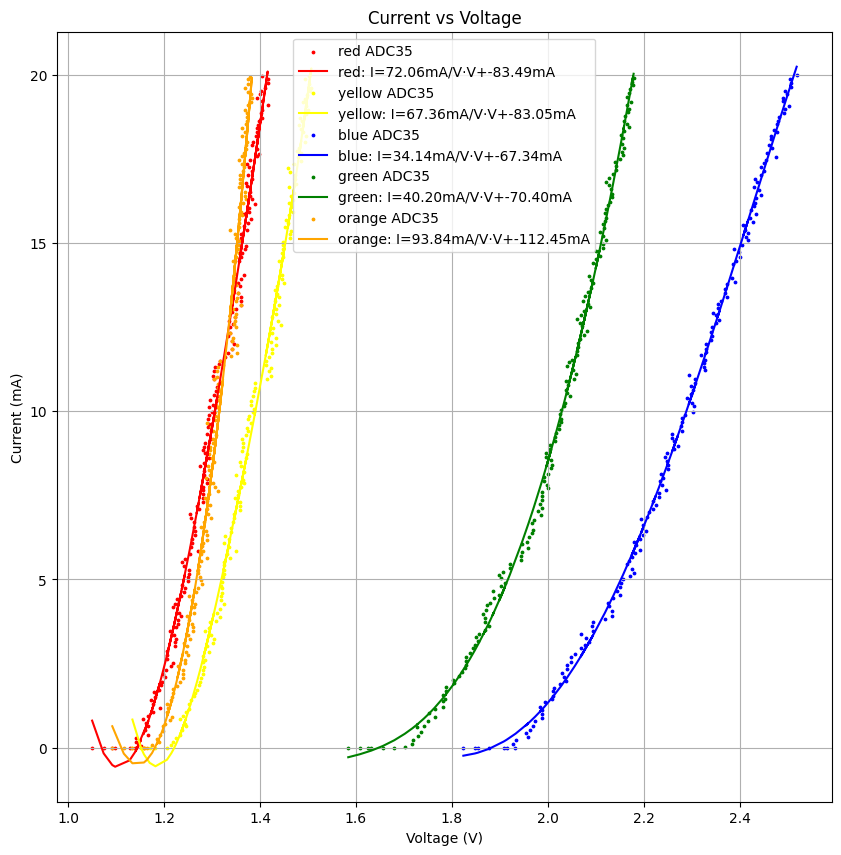

In [ ]:
# matplot LEDScorrect

plt.figure(figsize=(10, 10))

for color, file in data_files_correct.items():
    df = pd.read_csv(file)
    
    # Create current variables
    df['V_led']=df['Mediana_ADC1(34)_V'] * ((10000+2000)/2000) - df['Mediana_ADC2(35)_V']
    df['Iled']=df['Mediana_ADC2(35)_V']/100

    df = df[df['Iled'] <= 0.02]

    m, b = np.polyfit(df['V_led'], df['Iled'], 1)

    df['fit_old'] = a * df['V_led']**2 + b * df['V_led'] + c

    p = np.poly1d(np.polyfit(df['V_led'], df['Iled'], 4))
    
    df['fit'] = p(df['V_led'])

    # Plot I vs V (using dac_voltage as V)
    plt.scatter(df['V_led'], df['Iled']*1000,
             label=f'{color} ADC35', color=color, s=3)
    
    plt.plot(df['V_led'], df['fit']*1000, 
             label=f'{color}: I={m*1000:.2f}mA/V·V+{b*1000:.2f}mA', color=color)
    


plt.xlabel('Voltage (V)')
plt.ylabel('Current (mA)')
plt.title('Current vs Voltage')
plt.legend()
plt.grid(True)

plt.show()

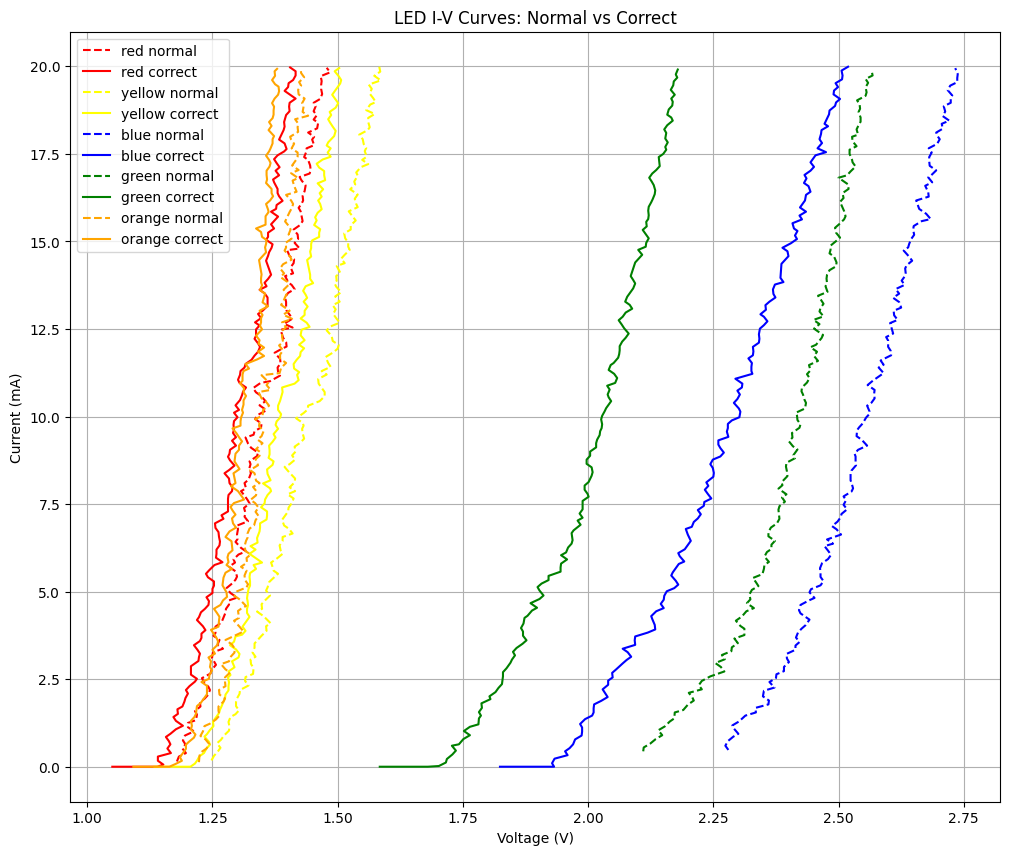

In [38]:
# matplot all together now

# Dictionaries for files
data_files = {
    "red": "lab_red.csv",
    "yellow": "lab_yellow.csv",
    "blue": "lab_blue.csv",
    "green": "lab_green.csv",
    "orange": "lab_orange.csv"
}

data_files_correct = {
    "red": "LEDScorrect_csv/LED_rojo.csv",
    "yellow": "LEDScorrect_csv/LED_amarillo.csv",
    "blue": "LEDScorrect_csv/LED_azul.csv",
    "green": "LEDScorrect_csv/LED_verde.csv",
    "orange": "LEDScorrect_csv/LED_naranja.csv"
}

plt.figure(figsize=(12, 10))

for color in data_files.keys():
    # Load normal data
    df = pd.read_csv(data_files[color])
    df['V_led'] = df['adc34_voltage'] * ((10000+2000)/2000) - df['adc35_voltage']
    df['Iled'] = df['adc35_voltage'] / 100
    df = df[df['Iled'] <= 0.02]
    p_norm = np.poly1d(np.polyfit(df['V_led'], df['Iled'], 4))
    df['fit'] = p_norm(df['V_led'])
    
    # Plot normal
    plt.plot(df['V_led'], df['Iled']*1000, label=f"{color} normal", linestyle='--', color=color)
    
    # Load correct data
    df_corr = pd.read_csv(data_files_correct[color])
    df_corr['V_led'] = df_corr['Mediana_ADC1(34)_V'] * ((10000+2000)/2000) - df_corr['Mediana_ADC2(35)_V']
    df_corr['Iled'] = df_corr['Mediana_ADC2(35)_V'] / 100
    df_corr = df_corr[df_corr['Iled'] <= 0.02]
    p_corr = np.poly1d(np.polyfit(df_corr['V_led'], df_corr['Iled'], 4))
    df_corr['fit'] = p_corr(df_corr['V_led'])
    
    # Plot corrected
    plt.plot(df_corr['V_led'], df_corr['Iled']*1000, label=f"{color} correct", color=color)

plt.xlabel("Voltage (V)")
plt.ylabel("Current (mA)")
plt.title("LED I-V Curves: Normal vs Correct")
plt.grid(True)
plt.legend()
plt.show()

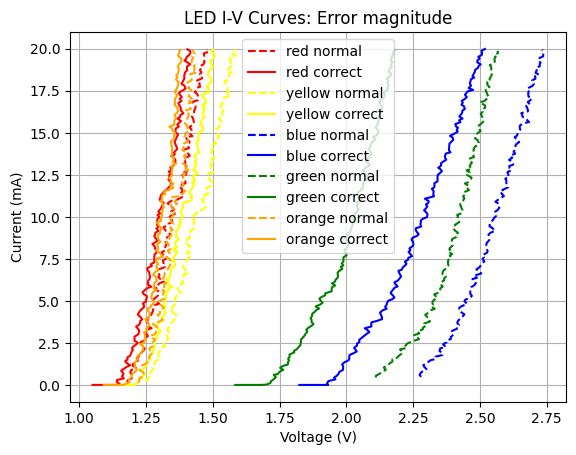

In [69]:
# matplot all together now

# Dictionaries for files
data_files = {
    "red": "lab_red.csv",
    "yellow": "lab_yellow.csv",
    "blue": "lab_blue.csv",
    "green": "lab_green.csv",
    "orange": "lab_orange.csv"
}

data_files_correct = {
    "red": "LEDScorrect_csv/LED_rojo.csv",
    "yellow": "LEDScorrect_csv/LED_amarillo.csv",
    "blue": "LEDScorrect_csv/LED_azul.csv",
    "green": "LEDScorrect_csv/LED_verde.csv",
    "orange": "LEDScorrect_csv/LED_naranja.csv"
}

# plt.figure(figsize=(12, 10))

fig = go.Figure()


for color in data_files.keys():
    # Load normal data
    df = pd.read_csv(data_files[color])
    df['V_led'] = df['adc34_voltage'] * ((10000+2000)/2000) - df['adc35_voltage']
    df['Iled'] = df['adc35_voltage'] / 100
    df = df[df['Iled'] <= 0.02]
    p_norm = np.poly1d(np.polyfit(df['V_led'], df['Iled'], 4))
    df['fit'] = p_norm(df['V_led'])
    
    # Plot normal
    plt.plot(df['V_led'], df['Iled']*1000, label=f"{color} normal", linestyle='--', color=color)
    
    # Load correct data
    df_corr = pd.read_csv(data_files_correct[color])
    df_corr['V_led'] = df_corr['Mediana_ADC1(34)_V'] * ((10000+2000)/2000) - df_corr['Mediana_ADC2(35)_V']
    df_corr['Iled'] = df_corr['Mediana_ADC2(35)_V'] / 100
    df_corr = df_corr[df_corr['Iled'] <= 0.02]
    p_corr = np.poly1d(np.polyfit(df_corr['V_led'], df_corr['Iled'], 4))
    df_corr['fit'] = p_corr(df_corr['V_led'])
    
    # Plot corrected
    plt.plot(df_corr['V_led'], df_corr['Iled']*1000, label=f"{color} correct", color=color)

    df['V_error'] = - df_corr['V_led'] + df['V_led']
    df['I_error'] = - df_corr['Iled']*1000 + df['Iled']*1000
    #plt.plot(df['dac_value'], df['V_error'], label=f"{color} V_error", color=color)

    #plt.plot(df['dac_value'], df['I_error'], label=f"{color} I_error", color=color)

        # Add traces
    fig.add_trace(go.Scatter(
        x=df['dac_value'],
        y=df['I_error'],
        mode='lines',
        name=f'{color} ADC35',
        line=dict(color=color, dash='solid')
    ))

    fig.add_trace(go.Scatter(
        x=df['dac_value'],
        y=df['V_error'],
        mode='lines',
        name=f'{color} ADC35',
        line=dict(color=color, dash='solid')
    ))

# Layout
fig.update_layout(
    title="Interactive Current vs Voltage",
    xaxis_title="dac value (bit))",
    yaxis_title="error",
    template="plotly_white",
    width=1000,
    height=800
)

fig.show()



plt.xlabel("Voltage (V)")
plt.ylabel("Current (mA)")
plt.title("LED I-V Curves: Error magnitude")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Plots from the csv directly and reaching 0

data_files = {
    "red": "lab_red.csv",
    "yellow": "lab_yellow.csv",
    "blue": "lab_blue.csv",
    "green": "lab_green.csv",
    "orange": "lab_orange.csv"
}

fig = go.Figure()

R = 100  # ohms
V1 = 10

for color, file in data_files.items():
    df = pd.read_csv(file)

    low_range = 0   # lower limit in A
    high_range = 0.02   # upper limit in A

    df = df[(df['Iled'] >= low_range) & (df['Iled'] <= high_range)]

    p = np.poly1d(np.polyfit(df['V_led'], df['Iled'], 4))
    
    df['fit'] = p(df['V_led'])

    V_fit = np.linspace(df['V_led'].min(), df['V_led'].max(), 200)
    I_fit = p(V_fit)

    # Find where fit crosses I=0
    # Extrapolate downward if needed
    if np.min(I_fit) > 0:  # polynomial doesn't reach zero
        # Solve p(V) = 0 numerically using numpy roots
        roots = p.r
        real_roots = roots[np.isreal(roots)].real
        # Pick the root below the minimum measured voltage
        V0 = min([r for r in real_roots if r <= df['V_led'].min()] + [df['V_led'].min() - 0.01])
        # Extend the fit down to I=0
        V_fit_extended = np.linspace(V0, df['V_led'].max(), 300)
        I_fit_extended = p(V_fit_extended)
        # Clip negative currents to 0
        I_fit_extended[I_fit_extended < 0] = 0
    else:
        V_fit_extended = V_fit
        I_fit_extended = I_fit

    # Add traces
    fig.add_trace(go.Scatter(
        x=df['V_led'],
        y=df['Iled']*1000,
        mode='markers',
        name=f'{color} ADC35',
        marker=dict(color=color, size=3)
    ))

    fig.add_trace(go.Scatter(
        x=V_fit_extended,
        y=I_fit_extended*1000,
        mode='lines',
        name=f'{color}: {a:.3f}V² + {b:.3f}V + {c:.3f}',
        line=dict(color=color, dash='solid')
    ))

# Layout
fig.update_layout(
    title="Interactive Current vs Voltage",
    xaxis_title="Voltage (V)",
    yaxis_title="Current (mA)",
    template="plotly_white",
    width=1000,
    height=800
)

fig.show()

In [116]:
# Plots from csv, reaching 0 no for

import pandas as pd
import numpy as np
import plotly.graph_objects as go

fig = go.Figure()

low_range = 0
high_range = 0.02

# --- RED LED ---
df_red = pd.read_csv("lab_red.csv")
df_red = df_red[(df_red['Iled'] >= low_range) & (df_red['Iled'] <= high_range)]

degree_red = 2  # polynomial degree for red
p_red = np.poly1d(np.polyfit(df_red['V_led'], df_red['Iled'], degree_red))

V_red = np.linspace(df_red['V_led'].min(), df_red['V_led'].max(), 200)
I_red = p_red(V_red)

# Extend to I=0 if needed
if np.min(I_red) > 0:
    roots = p_red.r
    real_roots = roots[np.isreal(roots)].real
    V0 = min([r for r in real_roots if r <= df_red['V_led'].min()] + [df_red['V_led'].min() - 0.01])
    V_red_ext = np.linspace(V0, df_red['V_led'].max(), 300)
    I_red_ext = p_red(V_red_ext)
    I_red_ext[I_red_ext < 0] = 0
else:
    V_red_ext = V_red
    I_red_ext = I_red

fig.add_trace(go.Scatter(
    x=df_red['V_led'],
    y=df_red['Iled']*1000,
    mode='markers',
    name='red ADC35',
    marker=dict(color='red', size=3)
))

fig.add_trace(go.Scatter(
    x=V_red_ext,
    y=I_red_ext*1000,
    mode='lines',
    name='red fit',
    line=dict(color='red')
))

# --- YELLOW LED ---
df_yellow = pd.read_csv("lab_yellow.csv")
df_yellow = df_yellow[(df_yellow['Iled'] >= low_range) & (df_yellow['Iled'] <= high_range)]

degree_yellow = 2  # different degree
p_yellow = np.poly1d(np.polyfit(df_yellow['V_led'], df_yellow['Iled'], degree_yellow))

V_yellow = np.linspace(df_yellow['V_led'].min(), df_yellow['V_led'].max(), 200)
I_yellow = p_yellow(V_yellow)

# Extend to I=0
if np.min(I_yellow) > 0:
    roots = p_yellow.r
    real_roots = roots[np.isreal(roots)].real
    V0 = min([r for r in real_roots if r <= df_yellow['V_led'].min()] + [df_yellow['V_led'].min() - 0.01])
    V_yellow_ext = np.linspace(V0, df_yellow['V_led'].max(), 300)
    I_yellow_ext = p_yellow(V_yellow_ext)
    I_yellow_ext[I_yellow_ext < 0] = 0
else:
    V_yellow_ext = V_yellow
    I_yellow_ext = I_yellow

fig.add_trace(go.Scatter(
    x=df_yellow['V_led'],
    y=df_yellow['Iled']*1000,
    mode='markers',
    name='yellow ADC35',
    marker=dict(color='yellow', size=3)
))

fig.add_trace(go.Scatter(
    x=V_yellow_ext,
    y=I_yellow_ext*1000,
    mode='lines',
    name='yellow fit',
    line=dict(color='yellow')
))

# --- blue LED ---
df_blue = pd.read_csv("lab_blue.csv")
df_blue = df_blue[(df_blue['Iled'] >= low_range) & (df_blue['Iled'] <= high_range)]

degree_blue = 4  # different degree
p_blue = np.poly1d(np.polyfit(df_blue['V_led'], df_blue['Iled'], degree_blue))

V_blue = np.linspace(df_blue['V_led'].min(), df_blue['V_led'].max(), 200)
I_blue = p_blue(V_blue)

# Extend to I=0
if np.min(I_blue) > 0:
    roots = p_blue.r
    real_roots = roots[np.isreal(roots)].real
    V0 = min([r for r in real_roots if r <= df_blue['V_led'].min()] + [df_blue['V_led'].min() - 0.01])
    V_blue_ext = np.linspace(V0, df_blue['V_led'].max(), 300)
    I_blue_ext = p_blue(V_blue_ext)
    I_blue_ext[I_blue_ext < 0] = 0
else:
    V_blue_ext = V_blue
    I_blue_ext = I_blue

fig.add_trace(go.Scatter(
    x=df_blue['V_led'],
    y=df_blue['Iled']*1000,
    mode='markers',
    name='blue ADC35',
    marker=dict(color='blue', size=3)
))

fig.add_trace(go.Scatter(
    x=V_blue_ext,
    y=I_blue_ext*1000,
    mode='lines',
    name='blue fit',
    line=dict(color='blue')
))

# --- GREEN LED ---
df_green = pd.read_csv("lab_green.csv")
df_green = df_green[(df_green['Iled'] >= low_range) & (df_green['Iled'] <= high_range)]

degree_green = 4  # different degree
p_green = np.poly1d(np.polyfit(df_green['V_led'], df_green['Iled'], degree_green))

V_green = np.linspace(df_green['V_led'].min(), df_green['V_led'].max(), 200)
I_green = p_green(V_green)

# Extend to I=0
if np.min(I_green) > 0:
    roots = p_green.r
    real_roots = roots[np.isreal(roots)].real
    V0 = min([r for r in real_roots if r <= df_green['V_led'].min()] + [df_green['V_led'].min() - 0.01])
    V_green_ext = np.linspace(V0, df_green['V_led'].max(), 300)
    I_green_ext = p_green(V_green_ext)
    I_green_ext[I_green_ext < 0] = 0
else:
    V_green_ext = V_green
    I_green_ext = I_green

fig.add_trace(go.Scatter(
    x=df_green['V_led'],
    y=df_green['Iled']*1000,
    mode='markers',
    name='green ADC35',
    marker=dict(color='green', size=3)
))

fig.add_trace(go.Scatter(
    x=V_green_ext,
    y=I_green_ext*1000,
    mode='lines',
    name='green fit',
    line=dict(color='green')
))

# --- ORANGE LED ---
df_orange = pd.read_csv("lab_orange.csv")
df_orange = df_orange[(df_orange['Iled'] >= low_range) & (df_orange['Iled'] <= high_range)]

degree_orange = 2  # different degree
p_orange = np.poly1d(np.polyfit(df_orange['V_led'], df_orange['Iled'], degree_orange))

V_orange = np.linspace(df_orange['V_led'].min(), df_orange['V_led'].max(), 200)
I_orange = p_orange(V_orange)

# Extend to I=0
if np.min(I_orange) > 0:
    roots = p_orange.r
    real_roots = roots[np.isreal(roots)].real
    V0 = min([r for r in real_roots if r <= df_orange['V_led'].min()] + [df_orange['V_led'].min() - 0.01])
    V_orange_ext = np.linspace(V0, df_orange['V_led'].max(), 300)
    I_orange_ext = p_orange(V_orange_ext)
    I_orange_ext[I_orange_ext < 0] = 0
else:
    V_orange_ext = V_orange
    I_orange_ext = I_orange

fig.add_trace(go.Scatter(
    x=df_orange['V_led'],
    y=df_orange['Iled']*1000,
    mode='markers',
    name='orange ADC35',
    marker=dict(color='orange', size=3)
))

fig.add_trace(go.Scatter(
    x=V_orange_ext,
    y=I_orange_ext*1000,
    mode='lines',
    name='orange fit',
    line=dict(color='orange')
))

fig.update_layout(
    title="LED I-V Curves with Individual Fits",
    xaxis_title="Voltage (V)",
    yaxis_title="Current (mA)",
    template="plotly_white",
    width=1000,
    height=800
)

fig.show()